# SQL DATABASE QUERY & INJECTION - DATA ANALYSIS PART 1

## Bhawandeep Kaur

In [124]:
# !pip install sql
# !pip install psycopg2-binary
# !pip install graphviz
# !pip install matplotlib pandas
# !pip install kaggle

In [125]:
# import libraries
import kagglehub
import sqlite3
import pandas as pd
import os
import math
import numpy as np
import glob
import matplotlib.pyplot as plt
from graphviz import Digraph
from IPython.display import Image, display
from matplotlib.ticker import ScalarFormatter


## 1. Creating Database

In [126]:
# Create/connect database
conn = sqlite3.connect("database.db")

print("Database connected successfully!")

Database connected successfully!


# 2. Connecting Database

In [127]:
# Connect database
conn = sqlite3.connect("database.db", timeout=30)
cursor = conn.cursor()

In [128]:
# Create table
cursor.execute("""
CREATE TABLE IF NOT EXISTS users (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    name TEXT,
    age INTEGER
)
""")

In [129]:
# Save changes
conn.commit()

print("Table created successfully!")

Table created successfully!


## Creating User

In [130]:
# Insert data
cursor.execute("""
INSERT INTO users (name, age)
VALUES ('Priya', 22)
""")

cursor.execute("""
INSERT INTO users (name, age)
VALUES ('Emily', 25)
""")

# Save data
conn.commit()
print("Data inserted")

Data inserted


## Read Database

In [131]:
# Read data
cursor.execute("SELECT * FROM users")

rows = cursor.fetchall()

print("\nAll Users:")
for row in rows:
    print(row)


All Users:
(9, 'Priya', 22)
(10, 'Emily', 25)


In [132]:
# Update data
cursor.execute("""
UPDATE users
SET age = 30
WHERE name = 'Emily'
""")

conn.commit()

print("\nData updated")


Data updated


In [133]:
# Read data
cursor.execute("SELECT * FROM users")

print("\nUpdated Users:")
for row in cursor.fetchall():
    print(row)


Updated Users:
(9, 'Priya', 22)
(10, 'Emily', 30)


## Deleting User

In [134]:
# delete data
cursor.execute("""
DELETE FROM users
WHERE name = 'Sara'
""")

conn.commit()

print("\nUser deleted")



User deleted


In [135]:
# final data
cursor.execute("SELECT * FROM users")

print("\nFinal Users:")
for row in cursor.fetchall():
    print(row)



Final Users:
(9, 'Priya', 22)
(10, 'Emily', 30)


In [136]:
# close database
conn.close()

print("\nDatabase closed")


Database closed


## Create Flowchart

In [137]:
# Create flowchart
flow = Digraph("SQLite_Flowchart", format="png")

flow.attr(rankdir="TB")

flow.node("A", "Start")
flow.node("B", "Import sqlite3")
flow.node("C", "Connect to database.db")
flow.node("D", "Create cursor")
flow.node("E", "Create users table")
flow.node("F", "Insert data")
flow.node("G", "Commit changes")
flow.node("H", "Read / SELECT data")
flow.node("I", "Update data")
flow.node("J", "Commit changes")
flow.node("K", "Delete data")
flow.node("L", "Commit changes")
flow.node("M", "Close database")
flow.node("N", "End")

# Connect nodes
flow.edges([
    ("A", "B"),
    ("B", "C"),
    ("C", "D"),
    ("D", "E"),
    ("E", "F"),
    ("F", "G"),
    ("G", "H"),
    ("H", "I"),
    ("I", "J"),
    ("J", "K"),
    ("K", "L"),
    ("L", "M"),
    ("M", "N")
])

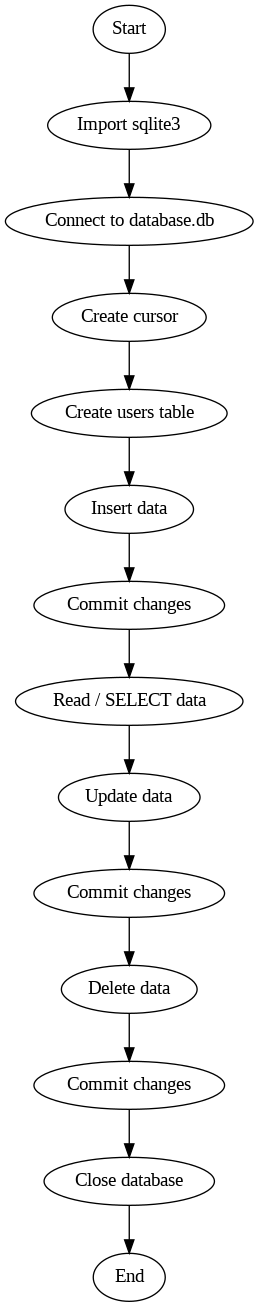

In [138]:
# Save flowchart
flow.render("sqlite_flowchart", cleanup=True)

# Display in notebook
display(Image(filename="sqlite_flowchart.png"))

In [139]:
# read database
conn = sqlite3.connect("database.db")
query = "SELECT name, age FROM users"

df = pd.read_sql(query, conn)

print(df)

    name  age
0  Priya   22
1  Emily   30


## Bar Plot

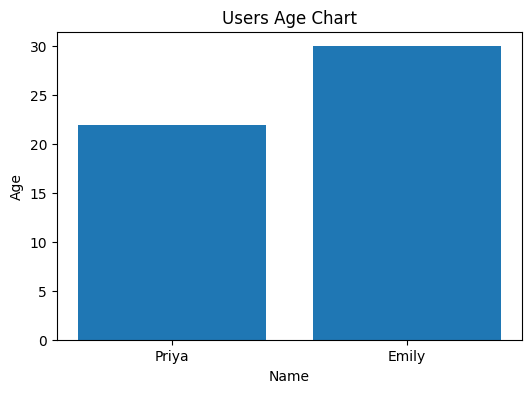

In [140]:
# plot data
plt.figure(figsize=(6,4))

plt.bar(df["name"], df["age"])

plt.xlabel("Name")
plt.ylabel("Age")
plt.title("Users Age Chart")

plt.show()
conn.close()

## Pie Chart

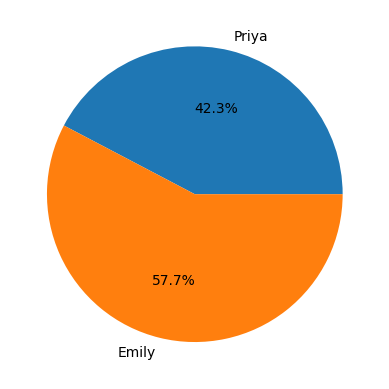

In [141]:
# pie plot
plt.pie(df["age"], labels=df["name"], autopct='%1.1f%%')
plt.show()

In [142]:
# connecting database
conn = sqlite3.connect("database.db")
cursor = conn.cursor()

## Deleting all records

In [143]:
# deleting all records
cursor.execute("""
DELETE FROM users
WHERE name IN ('Priya', 'Emily')
""")

conn.commit()

print("Old records deleted")

Old records deleted


## Pre Processing

### Loading Csv Files

In [144]:

csv_file = "product_price_dataset.csv"

In [145]:
print("Current folder:", os.getcwd())
print("File exists:", os.path.exists(csv_file))

Current folder: /content
File exists: True


In [146]:
df = pd.read_csv(csv_file)

## Inspecting Row & Columns

In [147]:
df.head()

,ProductID,ProductName,Brand,Category,Weight,Dimensions,Material,Color,Rating,NumReviews,Price
0,1,Laptop,XYZ Corp,Laptops,2.5,13x9x0.7,Aluminum,Silver,4.5,120,1200
1,2,Smartphone,ABC Inc,Mobile Phones,0.2,5.7x2.8x0.3,Glass,Black,4.8,300,800
2,3,Headphones,SoundWave,Electronics,0.4,8x7x2,Plastic,White,4.3,80,100
3,4,Smartwatch,TechGuru,Wearable Tech,0.1,1.5x1.5x0.4,Plastic,Black,4.6,150,250
4,5,Bluetooth Speaker,AudioKing,Audio Devices,1.0,7x7x3,Metal,Red,4.2,50,80


In [148]:
df.tail()

,ProductID,ProductName,Brand,Category,Weight,Dimensions,Material,Color,Rating,NumReviews,Price
115,116,Smart Luggage Tag,TagSmart,Travel & Luggage,0.1,4x2x0.2,Plastic,Black,4.6,150,15
116,117,Bluetooth Baby Monitor,BabyMonitor,Parenting & Baby Care,0.2,6x4x2,Plastic,White,4.5,120,40
117,118,Wireless Charging Coaster Set,ChargeSet,Home & Office,0.5,6x6x0.5,Plastic,Black,4.4,100,35
118,119,Smart Bike Light,BikeSmart,Cycling Accessories,0.1,4x2x1,Plastic,Red,4.7,200,25
119,120,Bluetooth Travel Speaker,TravelTunes,Audio Devices,0.3,6x4x2,Plastic,Black,4.6,180,60


In [149]:
conn = sqlite3.connect("database.db")
cursor = conn.cursor()

In [150]:
table_name = "product_price_dataset"

df.to_sql(
    table_name,
    conn,
    if_exists="replace",
    index=False
)

conn.commit()

print(f"Inserted {len(df)} rows into table: {table_name}")

Inserted 120 rows into table: product_price_dataset


In [151]:
test_df = pd.read_sql(
    f'SELECT * FROM "{table_name}" LIMIT 5',
    conn
)

print(test_df)

conn.close()

print("Database saved successfully!")

   ProductID        ProductName      Brand       Category  Weight  \
0          1             Laptop   XYZ Corp        Laptops     2.5   
1          2         Smartphone    ABC Inc  Mobile Phones     0.2   
2          3         Headphones  SoundWave    Electronics     0.4   
3          4         Smartwatch   TechGuru  Wearable Tech     0.1   
4          5  Bluetooth Speaker  AudioKing  Audio Devices     1.0   

    Dimensions  Material   Color  Rating  NumReviews  Price  
0     13x9x0.7  Aluminum  Silver     4.5         120   1200  
1  5.7x2.8x0.3     Glass   Black     4.8         300    800  
2        8x7x2   Plastic   White     4.3          80    100  
3  1.5x1.5x0.4   Plastic   Black     4.6         150    250  
4        7x7x3     Metal     Red     4.2          50     80  
Database saved successfully!


In [152]:
print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)


Dataset Shape:
(120, 11)

Column Names:
['ProductID', 'ProductName', 'Brand', 'Category', 'Weight', 'Dimensions', 'Material', 'Color', 'Rating', 'NumReviews', 'Price']

Data Types:
ProductID        int64
ProductName     object
Brand           object
Category        object
Weight         float64
Dimensions      object
Material        object
Color           object
Rating         float64
NumReviews       int64
Price            int64
dtype: object


In [153]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
ProductID      0
ProductName    0
Brand          0
Category       0
Weight         0
Dimensions     0
Material       0
Color          0
Rating         0
NumReviews     0
Price          0
dtype: int64


In [154]:
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
        ProductID      Weight      Rating  NumReviews        Price
count  120.000000  120.000000  120.000000  120.000000   120.000000
mean    60.500000    0.766250    4.486667  140.916667   100.666667
std     34.785054    1.609754    0.179604   60.349066   164.478975
min      1.000000    0.050000    4.000000   20.000000    10.000000
25%     30.750000    0.200000    4.400000   97.500000    30.000000
50%     60.500000    0.300000    4.500000  150.000000    50.000000
75%     90.250000    0.700000    4.600000  185.000000   100.000000
max    120.000000   12.000000    4.900000  300.000000  1200.000000


In [155]:
numeric_cols = df.select_dtypes(
    include=["int64", "float64"]
).columns

print("\nNumeric Columns:")
print(numeric_cols)


Numeric Columns:
Index(['ProductID', 'Weight', 'Rating', 'NumReviews', 'Price'], dtype='object')


In [156]:
for col in numeric_cols:

    print(f"\nStatistics for {col}")

    print("Mean:", df[col].mean())
    print("Median:", df[col].median())
    print("Mode:", df[col].mode()[0])
    print("Min:", df[col].min())
    print("Max:", df[col].max())
    print("Std Dev:", df[col].std())


Statistics for ProductID
Mean: 60.5
Median: 60.5
Mode: 1
Min: 1
Max: 120
Std Dev: 34.785054261852174

Statistics for Weight
Mean: 0.76625
Median: 0.3
Mode: 0.1
Min: 0.05
Max: 12.0
Std Dev: 1.609754437403261

Statistics for Rating
Mean: 4.486666666666666
Median: 4.5
Mode: 4.5
Min: 4.0
Max: 4.9
Std Dev: 0.17960429583178802

Statistics for NumReviews
Mean: 140.91666666666666
Median: 150.0
Mode: 200
Min: 20
Max: 300
Std Dev: 60.34906630530057

Statistics for Price
Mean: 100.66666666666667
Median: 50.0
Mode: 20
Min: 10
Max: 1200
Std Dev: 164.47897535348818


## Each Columns Distribution Plot

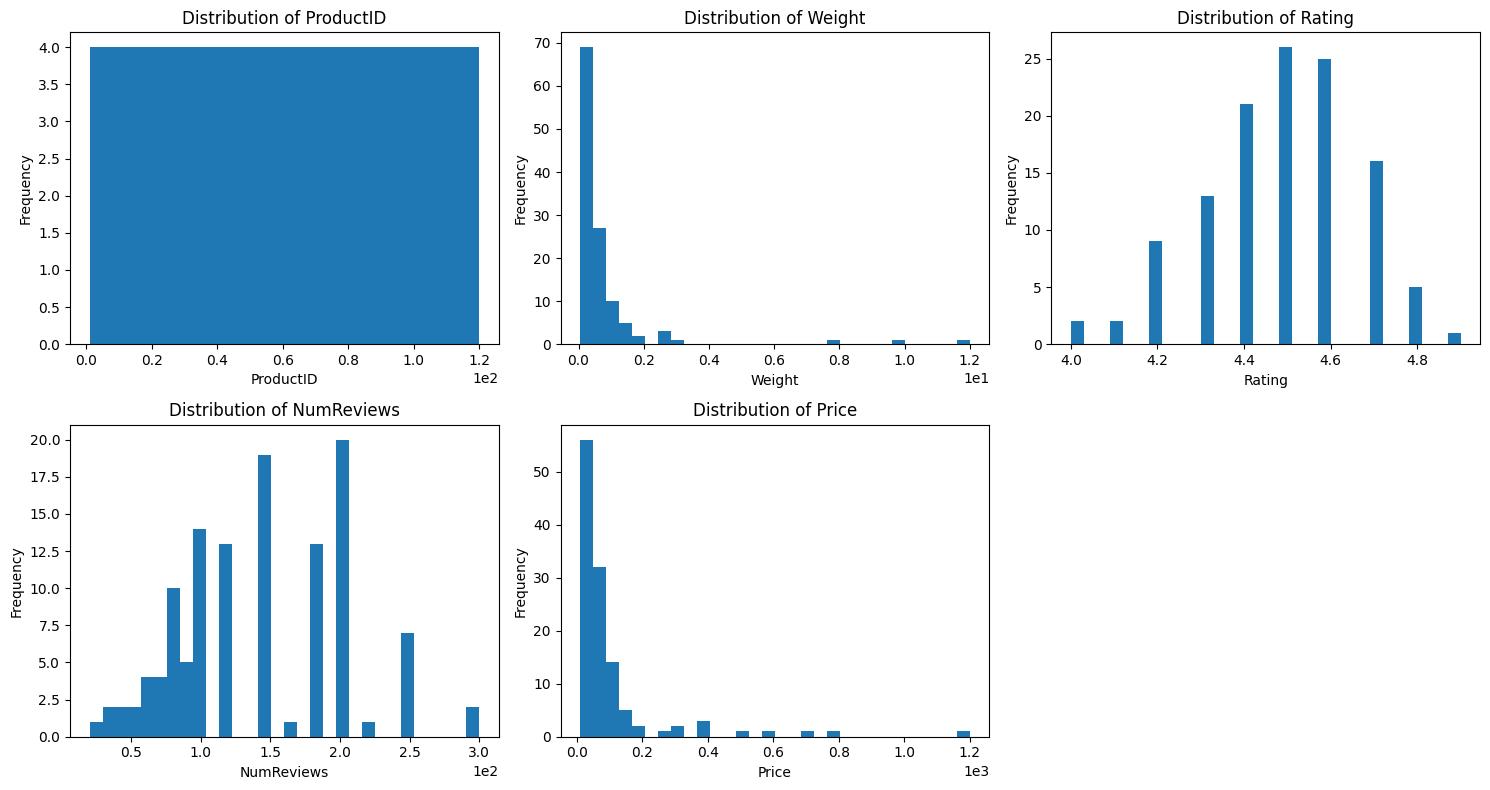

In [157]:
# numeric columns only
cols = df.select_dtypes(include=['int64', 'float64']).columns

n_cols = 3
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))

axes = axes.flatten()

for i, col in enumerate(cols):

    # convert explicitly to numeric
    data = pd.to_numeric(df[col], errors='coerce').dropna()

    axes[i].hist(data, bins=30)

    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")
    axes[i].set_title(f"Distribution of {col}")

    # scientific notation
    axes[i].ticklabel_format(axis='x', style='sci', scilimits=(0,0))

# remove empty axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Each Columns Box Plot

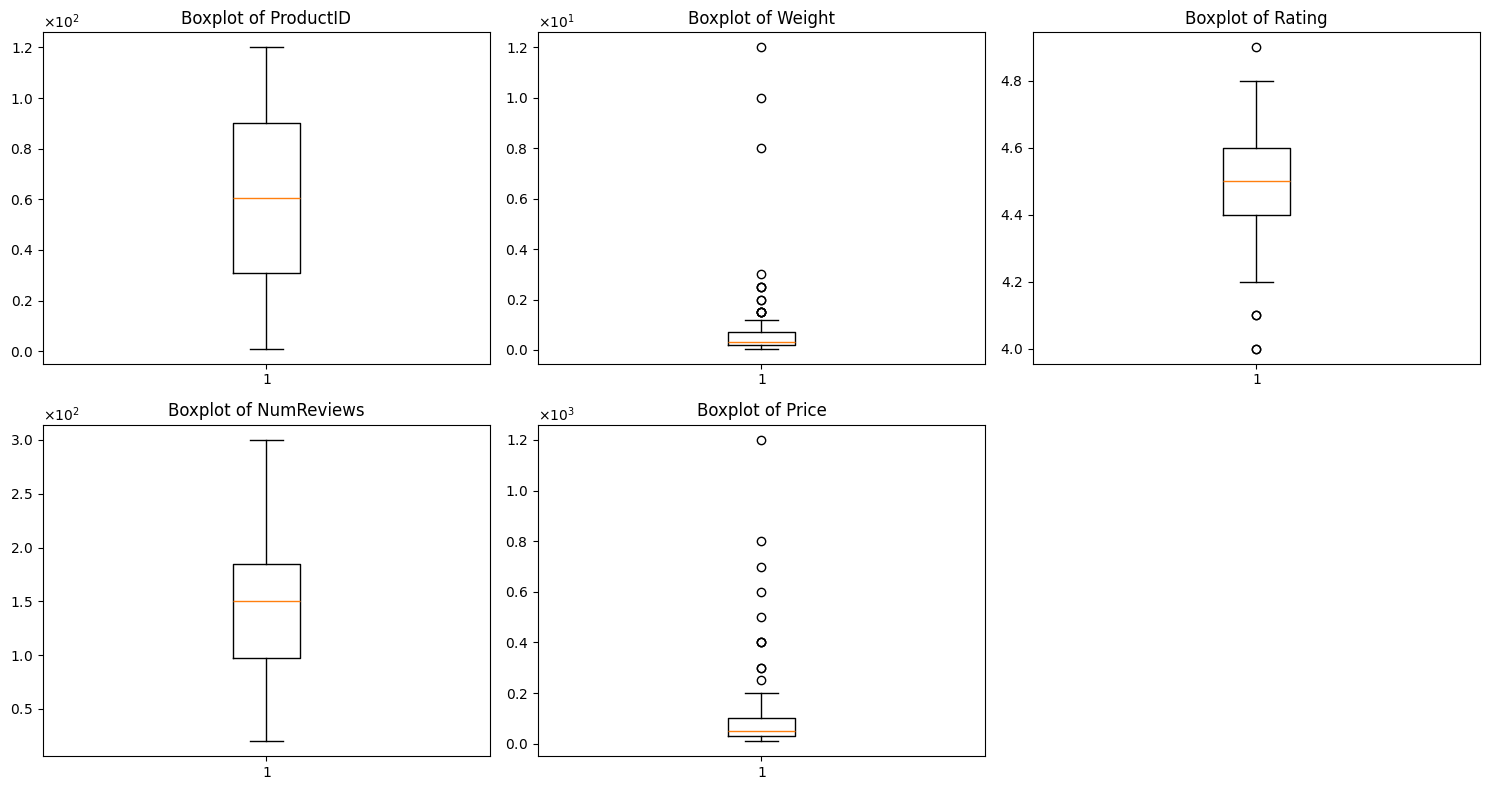

In [158]:
cols = numeric_cols

n_cols = 3
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))

axes = axes.flatten()

for i, col in enumerate(cols):

    data = df[col].dropna()

    axes[i].boxplot(data)

    axes[i].set_title(f"Boxplot of {col}")

    # Force scientific notation on Y-axis
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((0, 0))

    axes[i].yaxis.set_major_formatter(formatter)

# Remove empty plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Correlation Heat Map


Correlation Matrix:
            ProductID    Weight    Rating  NumReviews     Price
ProductID    1.000000 -0.107418  0.189520    0.369060 -0.399238
Weight      -0.107418  1.000000  0.151751    0.274401  0.459568
Rating       0.189520  0.151751  1.000000    0.675642  0.265281
NumReviews   0.369060  0.274401  0.675642    1.000000  0.195965
Price       -0.399238  0.459568  0.265281    0.195965  1.000000


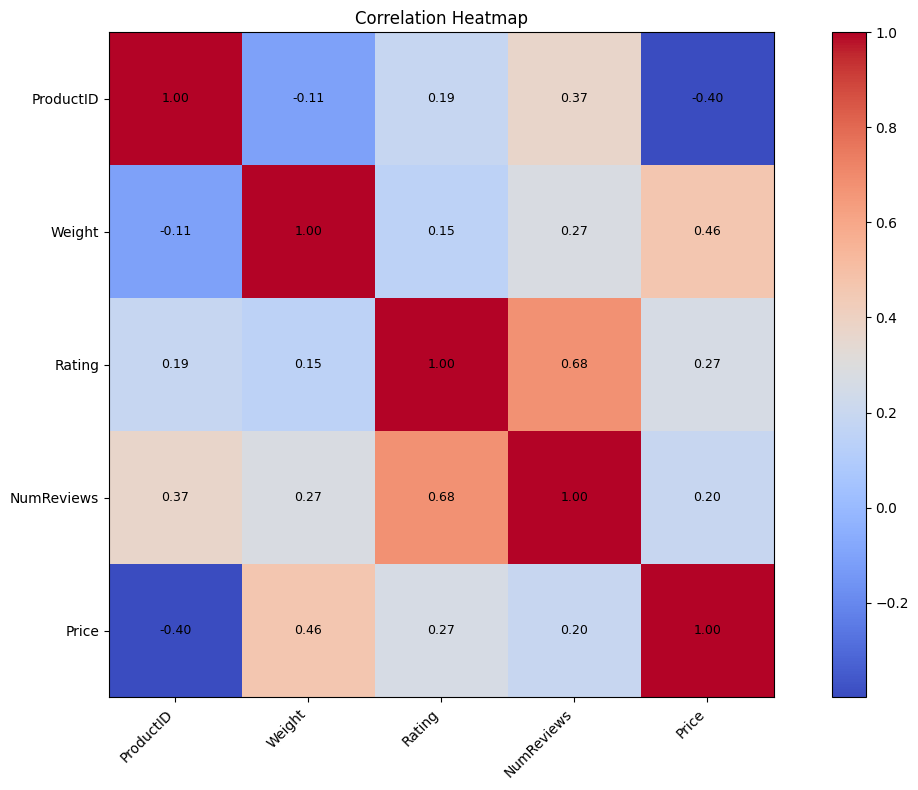

In [159]:
if len(numeric_cols) > 1:

    corr = df[numeric_cols].corr()

    print("\nCorrelation Matrix:")
    print(corr)

    # Create figure
    fig, ax = plt.subplots(figsize=(12, 8))

    # Heatmap
    heatmap = ax.imshow(corr, cmap="coolwarm")

    # Color bar
    cbar = plt.colorbar(heatmap)

    # Axis labels
    ax.set_xticks(np.arange(len(corr.columns)))
    ax.set_yticks(np.arange(len(corr.columns)))

    ax.set_xticklabels(corr.columns, rotation=45, ha="right")
    ax.set_yticklabels(corr.columns)

    # Add correlation values inside cells
    for i in range(len(corr.columns)):
        for j in range(len(corr.columns)):

            value = corr.iloc[i, j]

            ax.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=9
            )

    # Title
    plt.title("Correlation Heatmap")

    # Tight layout
    plt.tight_layout()

    plt.show()

## Top 10 Products


Text Columns:
Index(['ProductName', 'Brand', 'Category', 'Dimensions', 'Material', 'Color'], dtype='object')

Top values in ProductName:
ProductName
Laptop               1
Smartphone           1
Headphones           1
Smartwatch           1
Bluetooth Speaker    1
Gaming Console       1
Tablet               1
Camera               1
Drone                1
Fitness Tracker      1
Name: count, dtype: int64


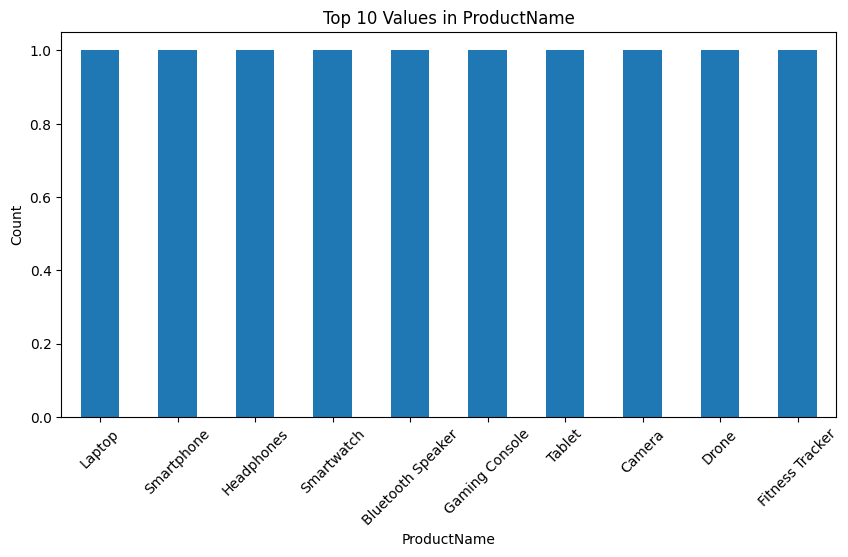

In [160]:
text_cols = df.select_dtypes(include=["object"]).columns

print("\nText Columns:")
print(text_cols)

if len(text_cols) > 0:

    col = text_cols[0]

    top_values = df[col].value_counts().head(10)

    print(f"\nTop values in {col}:")
    print(top_values)

    plt.figure(figsize=(10,5))

    top_values.plot(kind="bar")

    plt.title(f"Top 10 Values in {col}")

    plt.xlabel(col)
    plt.ylabel("Count")

    plt.xticks(rotation=45)

    plt.show()

In [161]:
conn.close()

print("\nStatistical analysis completed!")


Statistical analysis completed!


## Importing Ml Libraries

In [162]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [163]:
conn = sqlite3.connect("database.db")

df = pd.read_sql(
    "SELECT * FROM product_price_dataset",
    conn
)

conn.close()

print(df.head())
print(df.columns)

   ProductID        ProductName      Brand       Category  Weight  \
0          1             Laptop   XYZ Corp        Laptops     2.5   
1          2         Smartphone    ABC Inc  Mobile Phones     0.2   
2          3         Headphones  SoundWave    Electronics     0.4   
3          4         Smartwatch   TechGuru  Wearable Tech     0.1   
4          5  Bluetooth Speaker  AudioKing  Audio Devices     1.0   

    Dimensions  Material   Color  Rating  NumReviews  Price  
0     13x9x0.7  Aluminum  Silver     4.5         120   1200  
1  5.7x2.8x0.3     Glass   Black     4.8         300    800  
2        8x7x2   Plastic   White     4.3          80    100  
3  1.5x1.5x0.4   Plastic   Black     4.6         150    250  
4        7x7x3     Metal     Red     4.2          50     80  
Index(['ProductID', 'ProductName', 'Brand', 'Category', 'Weight', 'Dimensions',
       'Material', 'Color', 'Rating', 'NumReviews', 'Price'],
      dtype='object')


In [164]:
price_col = "Price"   # change if needed

df = df.dropna(subset=[price_col])

df["price_category"] = pd.qcut(
    df[price_col],
    q=3,
    labels=["Low", "Medium", "High"]
)

print(df["price_category"].value_counts())

price_category
Medium    47
Low       41
High      32
Name: count, dtype: int64


## Target & Feature Selection

In [165]:
X = df.drop(columns=[price_col, "price_category"])
y = df["price_category"]

In [166]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)


## Spliting Data into Train & Test

In [167]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [168]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            random_state=42
        ))
    ]
)

model.fit(X_train, y_train)

model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  Index(['ProductID', 'Weight', 'Rating', 'NumReviews'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['ProductName', 'Brand', 'Category', 'Dimensions', 'Material', 'Color'], dtype='object'))])),
                ('classifier',
                 RandomForestClassifier(n_estimators=300, random_state=42))])

## Prediction

In [169]:
y_pred = model.predict(X_test)

y_pred

array(['Medium', 'Medium', 'Low', 'Low', 'Medium', 'Medium', 'Low', 'Low',
       'High', 'Low', 'Medium', 'Low', 'Medium', 'Medium', 'Medium',
       'Medium', 'Medium', 'Medium', 'Medium', 'Medium', 'Low', 'Low',
       'Medium', 'Low'], dtype=object)

## Model Score

In [170]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5833333333333334
              precision    recall  f1-score   support

        High       1.00      0.14      0.25         7
         Low       0.67      0.75      0.71         8
      Medium       0.50      0.78      0.61         9

    accuracy                           0.58        24
   macro avg       0.72      0.56      0.52        24
weighted avg       0.70      0.58      0.54        24



## Confusion Matrix & Truth Table

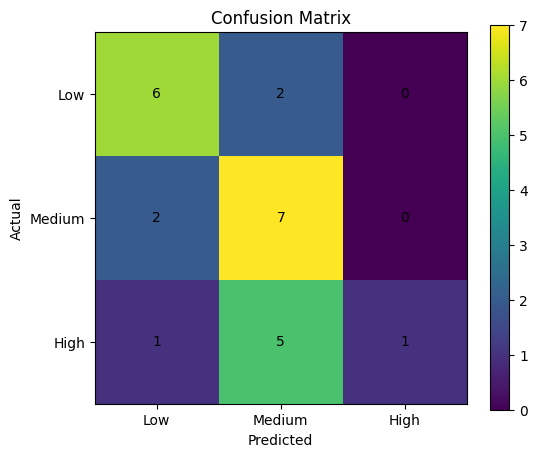

In [171]:
labels = ["Low", "Medium", "High"]

cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.colorbar()

plt.xticks(range(len(labels)), labels)
plt.yticks(range(len(labels)), labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

In [172]:
model2 = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", ExtraTreesClassifier(
            n_estimators=500,
            random_state=42
        ))
    ]
)

model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)

print("Extra Trees Accuracy:", accuracy_score(y_test, y_pred2))
print(classification_report(y_test, y_pred2))

Extra Trees Accuracy: 0.5416666666666666
              precision    recall  f1-score   support

        High       0.00      0.00      0.00         7
         Low       0.86      0.75      0.80         8
      Medium       0.44      0.78      0.56         9

    accuracy                           0.54        24
   macro avg       0.43      0.51      0.45        24
weighted avg       0.45      0.54      0.48        24

